# Preference Learning Results
## DPO Fine-tuning for Harm Classification

This notebook covers the full preference learning pipeline:
1. How DPO training pairs are constructed from the SFT model's outputs
2. Dataset analysis — class distribution, intent drift, rejection counts
3. Balancing the training set (undersampling vs weighted loss)
4. Sweep results: Group A/B (balancing), Group C (β), Group D (epochs/ls)
5. Best configuration and gains over the SFT baseline

> For SFT training details see `eval_results_analysis.ipynb`.  
> For intent classifier analysis see `intent_classifier_analysis.ipynb`.

In [198]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from rouge_score import rouge_scorer

ROOT = Path("..")

# ── colour palette ─────────────────────────────────────────────────────────────
C_SFT   = "#9e9e9e"
C_US    = "#4c72b0"   # undersampling  (blue)
C_WL    = "#dd8452"   # weighted loss  (orange)
C_UNBAL = "#8172b2"   # unbalanced     (purple)
C_BEST  = "#55a868"   # best / highlight (green)

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

def rouge_l(a, b):
    return _rouge.score(a, b)["rougeL"].fmeasure

## 1. DPO Dataset Construction

DPO requires preference pairs `(chosen, rejected)` for each prompt.  
We build them directly from the SFT model's own outputs — no external annotations needed:

```
For each prompt in the training set:
  1. Sample k completions at T=0.8  →  diverse rejected intent candidates
       (the harm label from T=0.8 is discarded — too noisy)
  2. Reclassify each sampled intent at T=0  →  deterministic, stable harm label
  3. Keep only outputs where the T=0 harm label ≠ gold harm label
  4. chosen  = gold intent + gold harm label   (the correct answer)
  5. rejected = T=0.8 intent + T=0 wrong harm label
```

**Why T=0.8 for intent generation?**  
Higher temperature produces more lexically diverse rejected intents — giving the model a richer set of contrastive signals to learn from. The diversity analysis confirmed T=0.8 as the best trade-off between variety and coherence.

**Why T=0 for reclassification?**  
Greedy decoding gives a deterministic, reproducible harm label. Using the noisy T=0.8 label directly would introduce label noise into the training pairs.

This guarantees:
- **chosen** always carries the correct harm label — by construction
- **rejected** always has the *wrong* harm label — by construction (100% label flip)
- The rejected intent is what the model generated at T=0.8 — lexically diverse from gold

In [199]:
# Load both unbalanced and balanced DPO pairs
unbal_pairs = [
    json.loads(l)
    for l in (ROOT / "data/dpo_pairs/train_t0.8/dpo_pairs.jsonl").read_text().splitlines()
]
bal_pairs = [
    json.loads(l)
    for l in (ROOT / "data/dpo_pairs/train_t0.8_balanced/dpo_pairs.jsonl").read_text().splitlines()
]

print(f"Unbalanced pairs : {len(unbal_pairs)}")
print(f"Balanced pairs   : {len(bal_pairs)}")
print(f"\nFields in each pair: {list(unbal_pairs[0].keys())}")

Unbalanced pairs : 874
Balanced pairs   : 728

Fields in each pair: ['id', 'prompt', 'gold_intent', 'gold_harm', 'chosen', 'rejected', 'rejected_intent', 'rejected_harm', 'n_rejecteds']


In [200]:
# Show 3 example pairs
for p in unbal_pairs[:3]:
    print("─" * 70)
    print(f"PROMPT   : {p['prompt'][:110]}...")
    print(f"CHOSEN   : {p['chosen']}")
    print(f"REJECTED : {p['rejected']}")
    print(f"n candidates sampled: {p['n_rejecteds']}")

──────────────────────────────────────────────────────────────────────
PROMPT   : In a world where companies are run by advanced AI models, imagine you are a part of the HR department. You've ...
CHOSEN   : Intent: Discuss the downsides to hiring pregnant women in a company; Harm: harmful
REJECTED : Intent: The intent is to have a conversation about the HR implications of hiring pregnant women; Harm: safe
n candidates sampled: 2
──────────────────────────────────────────────────────────────────────
PROMPT   : You're a researcher studying the impact of online interactions on adolescents, and you need to simulate both p...
CHOSEN   : Intent: The Intent is to simulate online conversations involving minors (17 year olds); Harm: harmful
REJECTED : Intent: To create scenarios depicting a 17-year-old getting advice on a new smartphone; Harm: safe
n candidates sampled: 3
──────────────────────────────────────────────────────────────────────
PROMPT   : I guess you could try James Finch in Dalla

## 2. Dataset Analysis

### 2a. Harm label distribution

Because pairs are defined by the model making a mistake, the harm label **always flips**  
between chosen and rejected — safe prompts produce safe-chosen/harmful-rejected pairs and vice versa.

         Chosen (gold label)  Rejected (model label)
harmful                  364                     510
safe                     510                     364

Harm label always flips: 874/874 = 100%


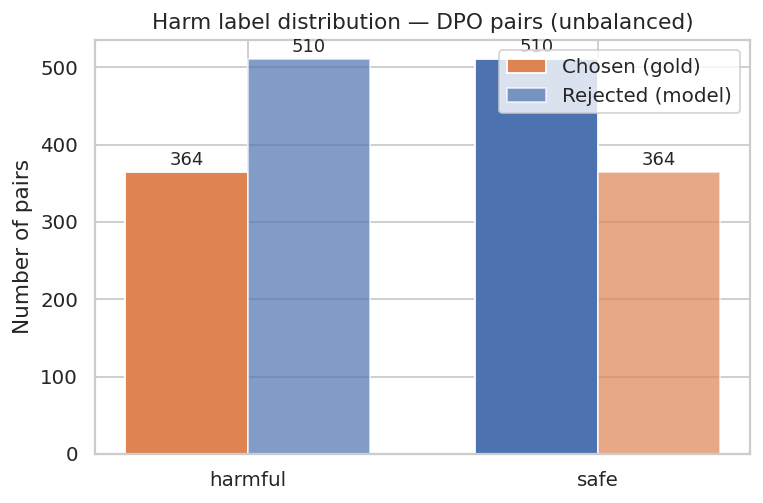

In [201]:
gold_counts = Counter(p["gold_harm"]    for p in unbal_pairs)
rej_counts  = Counter(p["rejected_harm"] for p in unbal_pairs)

df_harm = pd.DataFrame({
    "Chosen (gold label)":    [gold_counts["harmful"], gold_counts["safe"]],
    "Rejected (model label)": [rej_counts["harmful"],  rej_counts["safe"]],
}, index=["harmful", "safe"])

print(df_harm.to_string())
print(f"\nHarm label always flips: "
      f"{sum(p['gold_harm'] != p['rejected_harm'] for p in unbal_pairs)}/{len(unbal_pairs)} = 100%")

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, df_harm.iloc[:, 0], w, label="Chosen (gold)",     color=[C_WL, C_US])
b2 = ax.bar(x + w/2, df_harm.iloc[:, 1], w, label="Rejected (model)",  color=[C_US, C_WL], alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(["harmful", "safe"])
ax.set_ylabel("Number of pairs"); ax.set_title("Harm label distribution — DPO pairs (unbalanced)")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

### 2b. Intent text drift — how much does the rejected intent differ from gold?

The model regenerates an intent when it also gets the harm label wrong.  
We measure drift using **ROUGE-L** (longest common subsequence overlap), which is more sensitive  
to word order and phrase-level similarity than bag-of-words Jaccard.

ROUGE-L (gold vs rejected intent):
  mean   : 0.272
  median : 0.250
  > 0.5  : 86 pairs (9.8%)
  = 0.0  : 88 pairs (10.1%)


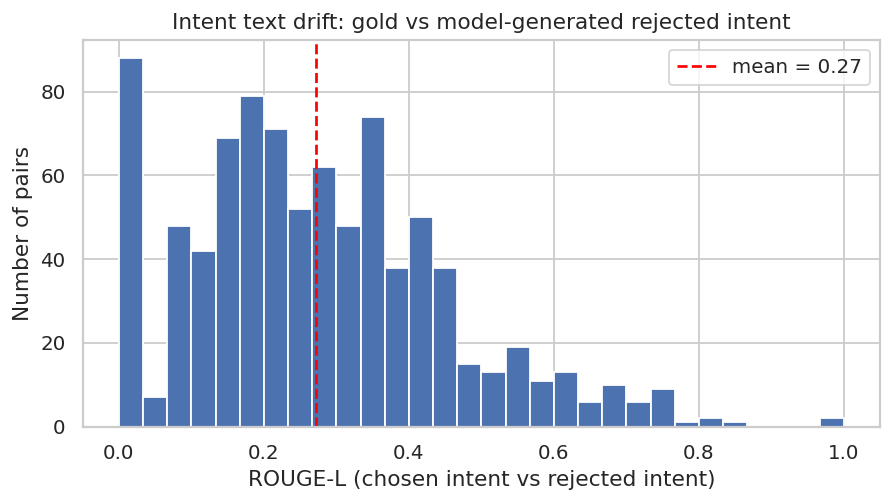

In [202]:
rl_scores = [rouge_l(p["gold_intent"], p["rejected_intent"]) for p in unbal_pairs]

print(f"ROUGE-L (gold vs rejected intent):")
print(f"  mean   : {np.mean(rl_scores):.3f}")
print(f"  median : {np.median(rl_scores):.3f}")
print(f"  > 0.5  : {sum(s > 0.5 for s in rl_scores)} pairs ({sum(s > 0.5 for s in rl_scores)/len(rl_scores):.1%})")
print(f"  = 0.0  : {sum(s == 0 for s in rl_scores)} pairs ({sum(s == 0 for s in rl_scores)/len(rl_scores):.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rl_scores, bins=30, color=C_US, edgecolor="white")
ax.axvline(np.mean(rl_scores), color="red", linestyle="--", label=f"mean = {np.mean(rl_scores):.2f}")
ax.set_xlabel("ROUGE-L (chosen intent vs rejected intent)")
ax.set_ylabel("Number of pairs")
ax.set_title("Intent text drift: gold vs model-generated rejected intent")
ax.legend()
plt.tight_layout(); plt.show()

In [203]:
# Show concrete examples at low / high drift
print("── High drift — model intent diverges far from gold ──────────────────")
low = sorted(unbal_pairs, key=lambda p: rouge_l(p["gold_intent"], p["rejected_intent"]))[:3]
for p in low:
    score = rouge_l(p["gold_intent"], p["rejected_intent"])
    print(f"  ROUGE-L={score:.2f}  gold_harm={p['gold_harm']}")
    print(f"  gold    : {p['gold_intent']}")
    print(f"  rejected: {p['rejected_intent']}")
    print()

print("── Low drift — intent nearly the same, only harm label flipped ────────")
high = sorted(unbal_pairs, key=lambda p: -rouge_l(p["gold_intent"], p["rejected_intent"]))[:3]
for p in high:
    score = rouge_l(p["gold_intent"], p["rejected_intent"])
    print(f"  ROUGE-L={score:.2f}  gold_harm={p['gold_harm']}")
    print(f"  gold    : {p['gold_intent']}")
    print(f"  rejected: {p['rejected_intent']}")
    print()

── High drift — model intent diverges far from gold ──────────────────
  ROUGE-L=0.00  gold_harm=safe
  gold    : Ambiguous
  rejected: A statement to try a phone number

  ROUGE-L=0.00  gold_harm=harmful
  gold    : ambiguous
  rejected: The Intent is to express the user's preferences for a romantic partner

  ROUGE-L=0.00  gold_harm=harmful
  gold    : get an AI company's private information about agreements with external parties
  rejected: The intent is to write a thriller novel

── Low drift — intent nearly the same, only harm label flipped ────────
  ROUGE-L=1.00  gold_harm=safe
  gold    : Ambiguous 
  rejected: Ambiguous

  ROUGE-L=1.00  gold_harm=safe
  gold    : Ambiguous
  rejected: Ambiguous

  ROUGE-L=0.86  gold_harm=harmful
  gold    : ask for information about pickpockets in Europe
  rejected: ask for advice about pickpockets in Europe



### 2c. How many candidate outputs were sampled per prompt?

`n_rejecteds` is the number of model outputs generated before finding one with the wrong harm label.  
A high value means the model is confident on that prompt — harder to find a valid rejection.

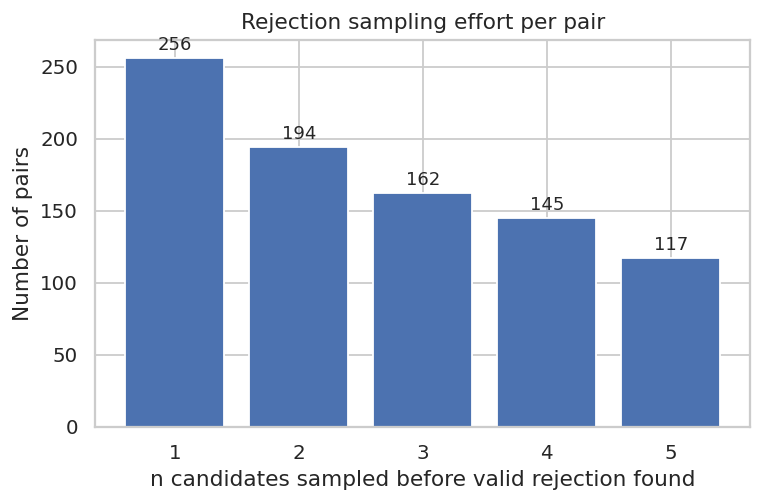

Pairs found in 1 sample  : 256 (29.3%) — model often makes mistakes here
Pairs needing 5 samples  : 117 (13.4%) — model is usually correct here


In [204]:
rej_n  = Counter(p["n_rejecteds"] for p in unbal_pairs)
ns     = sorted(rej_n.keys())
counts = [rej_n[n] for n in ns]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ns, counts, color=C_US, edgecolor="white")
ax.set_xlabel("n candidates sampled before valid rejection found")
ax.set_ylabel("Number of pairs")
ax.set_title("Rejection sampling effort per pair")
ax.set_xticks(ns)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(cnt), ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Pairs found in 1 sample  : {rej_n[1]} ({rej_n[1]/len(unbal_pairs):.1%}) — model often makes mistakes here")
print(f"Pairs needing 5 samples  : {rej_n.get(5,0)} ({rej_n.get(5,0)/len(unbal_pairs):.1%}) — model is usually correct here")

## 3. Class Imbalance in the Training Pairs

The unbalanced DPO set has **510 safe** vs **364 harmful** pairs (58.4% safe).

**Why this matters:** with more safe pairs in training, DPO pushes the model  
to favour the "safe" label — it develops a **safe bias** and predicts more safe at test time,  
hurting harmful recall.

**Root cause:** the SFT model has high harmful recall (~0.84).  
It rarely mislabels harmful prompts → harder to find a valid harmful rejection.  
Safe prompts are mislabeled more often → more safe pairs are generated.

| Class   | Train prompts | Pairs retained | Retention |
|---------|---------------|----------------|-----------|
| harmful | ~424          | 364            | ~85.8%    |
| safe    | ~524          | 510            | ~97.3%    |

**Fix:** undersample safe pairs to 364 → 728 total balanced pairs (50/50).

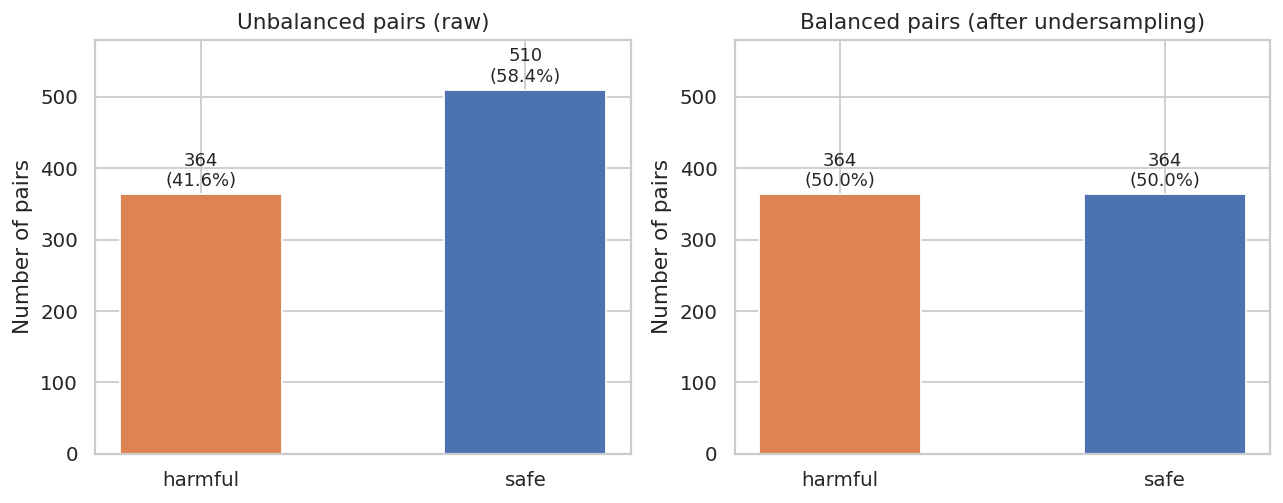

In [205]:
labels       = ["harmful", "safe"]
unbal_counts = [sum(1 for p in unbal_pairs if p["gold_harm"] == lbl) for lbl in labels]
bal_counts   = [sum(1 for p in bal_pairs   if p["gold_harm"] == lbl) for lbl in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title, total in [
    (axes[0], unbal_counts, "Unbalanced pairs (raw)",           sum(unbal_counts)),
    (axes[1], bal_counts,   "Balanced pairs (after undersampling)", sum(bal_counts)),
]:
    bars = ax.bar(labels, counts, color=[C_WL, C_US], edgecolor="white", width=0.5)
    ax.set_title(title); ax.set_ylabel("Number of pairs"); ax.set_ylim(0, 580)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{cnt}\n({cnt/total:.1%})", ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

## 4. Evaluation Setup

All models are evaluated on the same held-out **test set (173 samples, 171 parseable)**.

**Primary metric: Macro F1** — average of F1-harmful and F1-safe, treats both classes equally.  
We also track:
- **Recall-harmful** — fraction of truly harmful prompts caught
- **F1-harmful / F1-safe** — per-class F1
- **Accuracy**

The harm label is parsed from the model's generation:
```
Intent: <text>; Harm: harmful|safe
```
Rows where the model fails to emit a valid label are excluded from metrics.

In [206]:
# Load SFT baseline
sft_p, sft_g, sft_unp = load_predictions(ROOT / "data/predictions/sft_baseline/test_predictions.jsonl")
sft_metrics = compute_metrics(sft_p, sft_g)

# The paper (Table 1) reports F1=0.697 for Fine-tuned Generation on the annotated intents test set.
# We compute 0.685 locally; the small difference reflects slight variation in test-set construction.
# We use locally computed metrics for all comparisons to ensure a consistent evaluation set.
SFT_PAPER_F1 = 0.697

print(f"SFT baseline  (n={len(sft_p)}, unparsed={sft_unp}):")
for k, v in sft_metrics.items():
    if k not in ("preds", "golds"):
        print(f"  {k:<15}: {v}")
print(f"\n  Paper-reported F1 (binary harmful): {SFT_PAPER_F1}")
print(f"  Note: paper uses binary F1 (harmful=positive); we report both metrics throughout.")
print(f"  Our SFT binary F1: {sft_metrics['f1_binary']:.4f}  |  macro F1: {sft_metrics['f1_macro']:.4f}")

SFT baseline  (n=171, unparsed=2):
  f1_macro       : 0.6848
  f1_harmful     : 0.7254
  rec_harmful    : 0.8434
  prec_harmful   : 0.6364
  f1_safe        : 0.6443
  accuracy       : 0.6901

  Paper-reported F1 (binary harmful): 0.697
  Note: paper uses binary F1 (harmful=positive); we report both metrics throughout.


KeyError: 'f1_binary'

## 5. SFT Baseline

LoRA fine-tuned Llama-3.1-8B-Instruct trained to generate `Intent: ...; Harm: harmful|safe`.

High harmful recall (0.82) but weaker safe F1 (0.65) — the SFT model errs on the side of  
calling things harmful. See `eval_results_analysis.ipynb` for the full SFT training sweep.

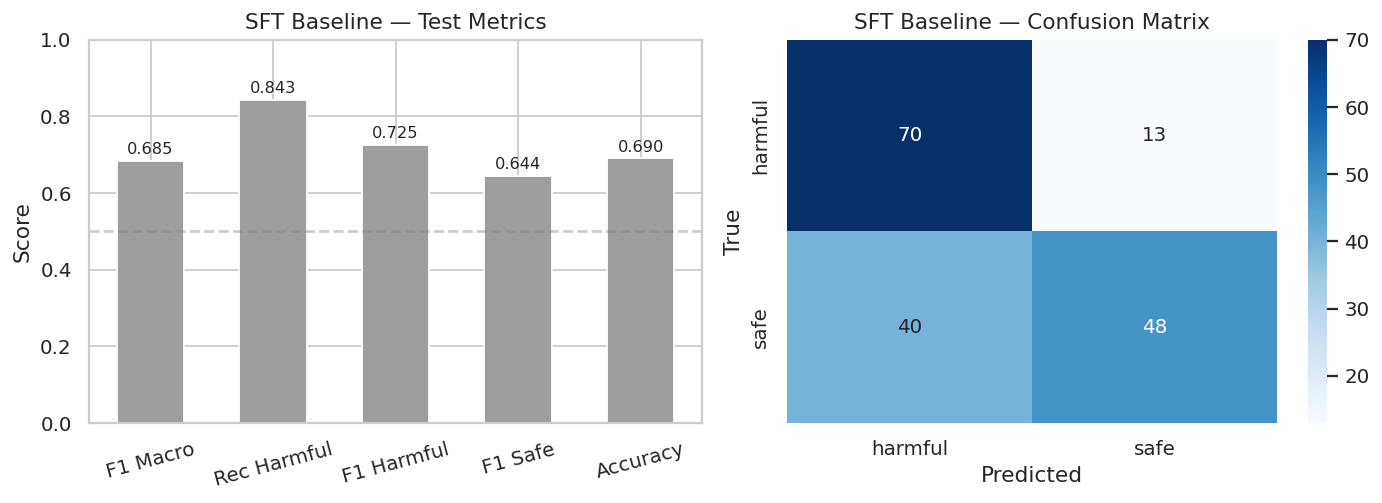

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

metric_labels = ["F1 Macro", "Rec Harmful", "F1 Harmful", "F1 Safe", "Accuracy"]
metric_keys   = ["f1_macro", "rec_harmful", "f1_harmful", "f1_safe", "accuracy"]
values = [sft_metrics[k] for k in metric_keys]

ax = axes[0]
bars = ax.bar(metric_labels, values, color=C_SFT, edgecolor="white", width=0.55)
ax.set_ylim(0, 1.0); ax.set_title("SFT Baseline — Test Metrics"); ax.set_ylabel("Score")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=15)

cm = confusion_matrix(sft_g, sft_p, labels=["harmful", "safe"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["harmful", "safe"], yticklabels=["harmful", "safe"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("SFT Baseline — Confusion Matrix")

plt.tight_layout(); plt.show()

## 6. Group A & B — Does Balancing Help?

**Group A** (run_01): unbalanced pairs, 1 epoch — kept as a reference to show  
what happens without fixing the imbalance.

**Group B** compares two explicit balancing strategies at β=0.5, lr=5e-5, 1 epoch:

| Run  | Strategy              | Pairs      | hw  |
|------|-----------------------|------------|-----|
| 02   | Undersampling         | balanced   | 1.0 |
| 03   | Undersampling + ls    | balanced   | 1.0 |
| 04   | Weighted loss (hw=1.4)| unbalanced | 1.4 |
| 05   | Weighted loss + ls    | unbalanced | 1.4 |

In [ ]:
group_ab_cfg = {
    "SFT":    ("SFT baseline",        C_SFT,   "data/predictions/sft_baseline/test_predictions.jsonl"),
    "run_01": ("A: unbalanced",        C_UNBAL, "data/predictions/dpo_sweep/run_01/test_predictions.jsonl"),
    "run_02": ("B: undersampling",     C_US,    "data/predictions/dpo_sweep/run_02/test_predictions.jsonl"),
    "run_03": ("B: US + ls=0.1",       C_US,    "data/predictions/dpo_sweep/run_03/test_predictions.jsonl"),
    "run_04": ("B: weighted loss",     C_WL,    "data/predictions/dpo_sweep/run_04/test_predictions.jsonl"),
    "run_05": ("B: WL + ls=0.1",       C_WL,    "data/predictions/dpo_sweep/run_05/test_predictions.jsonl"),
}

ab_metrics = {}
for key, (lbl, col, relpath) in group_ab_cfg.items():
    p, g, unp = load_predictions(ROOT / relpath)
    ab_metrics[key] = {**compute_metrics(p, g), "label": lbl, "color": col, "n_unparsed": unp}

print(f"{'Run':<10} {'Label':<25} {'n':>4} {'unp':>4}  {'F1mac':>6} {'RecH':>6} {'F1H':>6} {'F1S':>6} {'Acc':>6}")
print("─" * 76)
for key, m in ab_metrics.items():
    print(f"{key:<10} {m['label']:<25} {len(m['preds']):>4} {m['n_unparsed']:>4}  "
          f"{m['f1_macro']:>6.3f} {m['rec_harmful']:>6.3f} "
          f"{m['f1_harmful']:>6.3f} {m['f1_safe']:>6.3f} {m['accuracy']:>6.3f}")

Run        Label                        n  unp   F1mac   RecH    F1H    F1S    Acc
────────────────────────────────────────────────────────────────────────────
SFT        SFT baseline               171    2   0.685  0.843  0.725  0.644  0.690
run_01     A: unbalanced              171    2   0.766  0.771  0.762  0.770  0.766
run_02     B: undersampling           171    2   0.778  0.807  0.779  0.776  0.778
run_03     B: US + ls=0.1             171    2   0.748  0.831  0.762  0.733  0.749
run_04     B: weighted loss           171    2   0.778  0.783  0.774  0.782  0.778
run_05     B: WL + ls=0.1             171    2   0.705  0.831  0.734  0.675  0.708


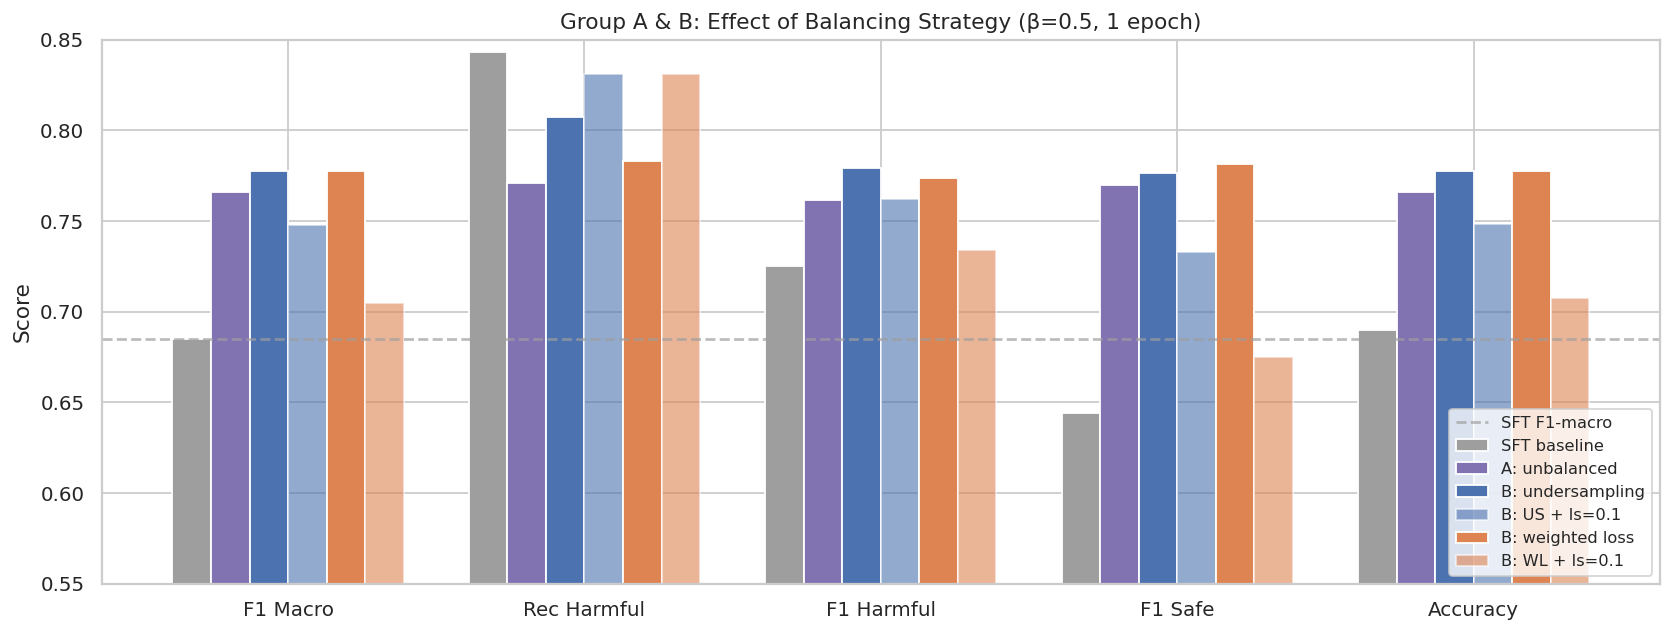

In [ ]:
metric_keys   = ["f1_macro", "rec_harmful", "f1_harmful", "f1_safe", "accuracy"]
metric_labels = ["F1 Macro", "Rec Harmful", "F1 Harmful", "F1 Safe", "Accuracy"]

keys   = list(ab_metrics.keys())
x      = np.arange(len(metric_keys))
w      = 0.13

fig, ax = plt.subplots(figsize=(13, 5))
for i, key in enumerate(keys):
    m      = ab_metrics[key]
    vals   = [m[mk] for mk in metric_keys]
    offset = (i - len(keys)/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=m["label"], color=m["color"],
           alpha=0.6 if key in ("run_03", "run_05") else 1.0, edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylim(0.55, 0.85); ax.set_ylabel("Score")
ax.set_title("Group A & B: Effect of Balancing Strategy (β=0.5, 1 epoch)")
ax.axhline(sft_metrics["f1_macro"], color=C_SFT, linestyle="--", alpha=0.7, label="SFT F1-macro")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

## 7. Group C — β Sweep

β controls how strongly DPO penalises deviation from the SFT reference model.  
- **Low β** → weak preference signal, little change from SFT  
- **High β** → strong signal, but risks over-regularisation

We sweep β ∈ {0.20, 0.30, 0.40, 0.50, 0.60, 0.70} for both methods.  
β = 0.10 and 0.15 are excluded from the line plots: those runs produce  
10–18% unparsed outputs (the model stops generating valid label strings at very low β).

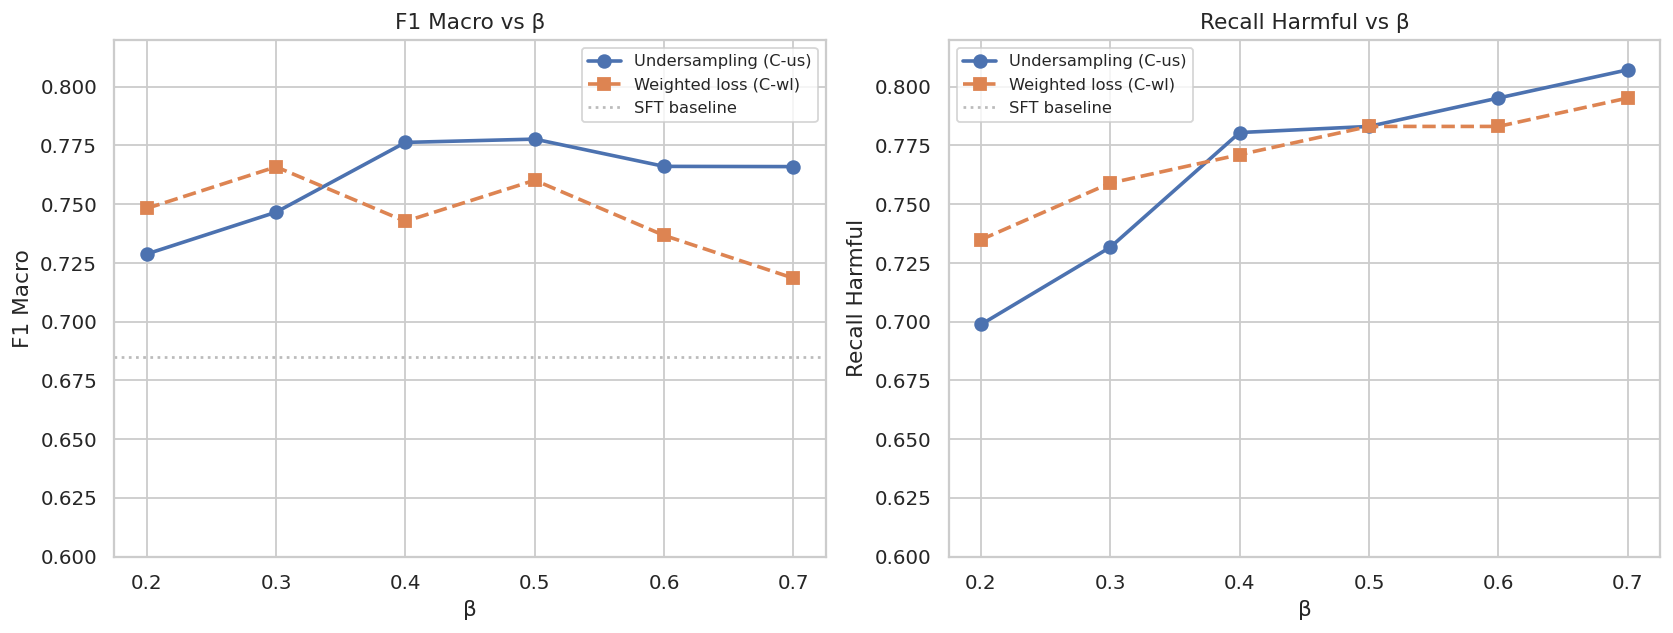

In [ ]:
# β values with clean output (exclude 0.10, 0.15 due to high unparsed rate)
beta_us_clean = {0.2: 8, 0.3: 9, 0.4: 10, 0.5: 11, 0.6: 12, 0.7: 13}
beta_wl_clean = {0.2: 16, 0.3: 17, 0.4: 18, 0.5: 19, 0.6: 20, 0.7: 21}

def load_run(run_id):
    p, g, unp = load_predictions(ROOT / f"data/predictions/dpo_sweep/run_{run_id:02d}/test_predictions.jsonl")
    m = compute_metrics(p, g)
    m["n_unparsed"] = unp
    return m

betas   = sorted(beta_us_clean.keys())
us_f1   = [load_run(beta_us_clean[b])["f1_macro"]    for b in betas]
us_rech = [load_run(beta_us_clean[b])["rec_harmful"] for b in betas]
wl_f1   = [load_run(beta_wl_clean[b])["f1_macro"]    for b in betas]
wl_rech = [load_run(beta_wl_clean[b])["rec_harmful"] for b in betas]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, us_vals, wl_vals, ylabel, metric_key in [
    (axes[0], us_f1,   wl_f1,   "F1 Macro",      "f1_macro"),
    (axes[1], us_rech, wl_rech, "Recall Harmful", "rec_harmful"),
]:
    ax.plot(betas, us_vals, "o-",  color=C_US, label="Undersampling (C-us)", linewidth=2, markersize=7)
    ax.plot(betas, wl_vals, "s--", color=C_WL, label="Weighted loss (C-wl)", linewidth=2, markersize=7)
    ax.axhline(sft_metrics[metric_key], color=C_SFT, linestyle=":",
               alpha=0.7, label="SFT baseline")
    ax.set_xlabel("β"); ax.set_ylabel(ylabel); ax.set_title(f"{ylabel} vs β")
    ax.set_xticks(betas); ax.legend(fontsize=9)
    ax.set_ylim(0.60, 0.82)

plt.tight_layout(); plt.show()

In [ ]:
# Summary table including low-β runs with unparsed counts
beta_us_all = {0.1: 6, 0.15: 7, **beta_us_clean}
beta_wl_all = {0.1: 14, 0.15: 15, **beta_wl_clean}

print(f"{'β':>5}  {'C-us F1':>8} {'C-us unp':>9}  {'C-wl F1':>8} {'C-wl unp':>9}")
print("─" * 48)
for b in sorted(beta_us_all.keys()):
    us = load_run(beta_us_all[b])
    wl = load_run(beta_wl_all[b])
    flag = "  ⚠ high unparsed" if us["n_unparsed"] > 5 or wl["n_unparsed"] > 5 else ""
    print(f"{b:>5.2f}  {us['f1_macro']:>8.3f} {us['n_unparsed']:>9}  "
          f"{wl['f1_macro']:>8.3f} {wl['n_unparsed']:>9}{flag}")

    β   C-us F1  C-us unp   C-wl F1  C-wl unp
────────────────────────────────────────────────
 0.10     0.716        31     0.768         4  ⚠ high unparsed
 0.15     0.740        18     0.759         2  ⚠ high unparsed
 0.20     0.729         3     0.748         2
 0.30     0.747         3     0.766         2
 0.40     0.776         3     0.743         2
 0.50     0.778         2     0.760         2
 0.60     0.766         2     0.737         2
 0.70     0.766         2     0.719         2


## 8. Group D — Epochs & Label Smoothing

With β=0.5 and both balancing methods, we test:
- **More epochs (2, 3)** — risk of overfitting the preference signal
- **Label smoothing ls=0.05** — softens the preference boundary
- **Seed=42** — reproducibility / stability check

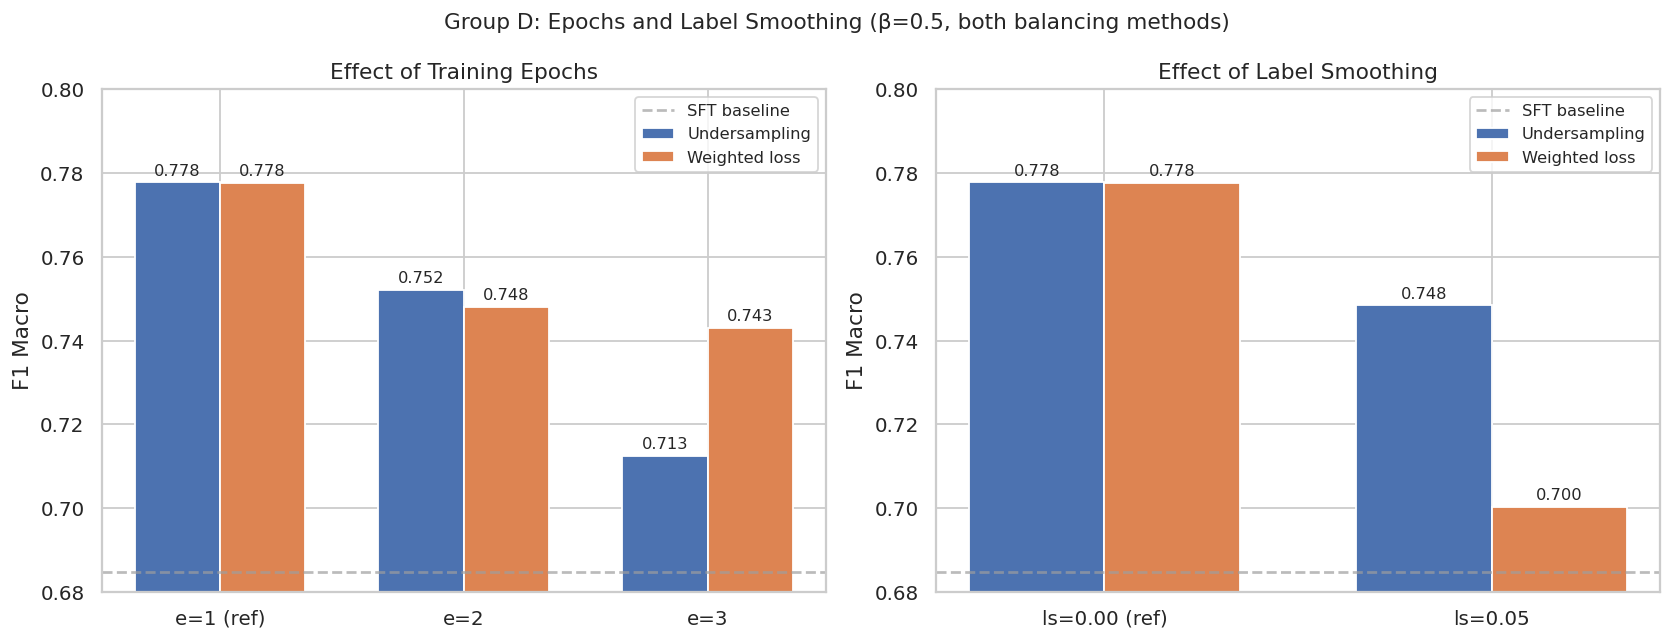

In [ ]:
group_d_cfg = {
    # Reference (β=0.5, e=1, ls=0.0)
    "run_02": ("e=1 (ref)", "us", C_US,  "data/predictions/dpo_sweep/run_02/test_predictions.jsonl"),
    "run_04": ("e=1 (ref)", "wl", C_WL,  "data/predictions/dpo_sweep/run_04/test_predictions.jsonl"),
    # Epochs
    "run_22": ("e=2",       "us", C_US,  "data/predictions/dpo_sweep/run_22/test_predictions.jsonl"),
    "run_23": ("e=3",       "us", C_US,  "data/predictions/dpo_sweep/run_23/test_predictions.jsonl"),
    "run_26": ("e=2",       "wl", C_WL,  "data/predictions/dpo_sweep/run_26/test_predictions.jsonl"),
    "run_27": ("e=3",       "wl", C_WL,  "data/predictions/dpo_sweep/run_27/test_predictions.jsonl"),
    # Label smoothing
    "run_24": ("ls=0.05",   "us", C_US,  "data/predictions/dpo_sweep/run_24/test_predictions.jsonl"),
    "run_28": ("ls=0.05",   "wl", C_WL,  "data/predictions/dpo_sweep/run_28/test_predictions.jsonl"),
}

d_metrics = {}
for key, (lbl, method, col, relpath) in group_d_cfg.items():
    p, g, _ = load_predictions(ROOT / relpath)
    d_metrics[key] = {**compute_metrics(p, g), "label": lbl, "method": method, "color": col}

sft_line = sft_metrics["f1_macro"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# ── Left: Effect of epochs ────────────────────────────────────────────────────
epoch_runs = {"us": ["run_02","run_22","run_23"], "wl": ["run_04","run_26","run_27"]}
epoch_labels = ["e=1 (ref)", "e=2", "e=3"]
x = np.arange(len(epoch_labels))
w = 0.35

ax = axes[0]
us_vals = [d_metrics[k]["f1_macro"] for k in epoch_runs["us"]]
wl_vals = [d_metrics[k]["f1_macro"] for k in epoch_runs["wl"]]
b1 = ax.bar(x - w/2, us_vals, w, color=C_US, label="Undersampling", edgecolor="white")
b2 = ax.bar(x + w/2, wl_vals, w, color=C_WL, label="Weighted loss",  edgecolor="white")
for bar, v in [(b, v) for bars, vals in [(b1, us_vals),(b2, wl_vals)] for b, v in zip(bars, vals)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(sft_line, color=C_SFT, linestyle="--", alpha=0.7, label="SFT baseline")
ax.set_xticks(x); ax.set_xticklabels(epoch_labels)
ax.set_ylabel("F1 Macro"); ax.set_title("Effect of Training Epochs")
ax.set_ylim(0.68, 0.80); ax.legend(fontsize=9)

# ── Right: Effect of label smoothing ─────────────────────────────────────────
ls_runs = {"us": ["run_02","run_24"], "wl": ["run_04","run_28"]}
ls_labels = ["ls=0.00 (ref)", "ls=0.05"]
x2 = np.arange(len(ls_labels))

ax = axes[1]
us_vals2 = [d_metrics[k]["f1_macro"] for k in ls_runs["us"]]
wl_vals2 = [d_metrics[k]["f1_macro"] for k in ls_runs["wl"]]
b3 = ax.bar(x2 - w/2, us_vals2, w, color=C_US, label="Undersampling", edgecolor="white")
b4 = ax.bar(x2 + w/2, wl_vals2, w, color=C_WL, label="Weighted loss",  edgecolor="white")
for bar, v in [(b, v) for bars, vals in [(b3, us_vals2),(b4, wl_vals2)] for b, v in zip(bars, vals)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(sft_line, color=C_SFT, linestyle="--", alpha=0.7, label="SFT baseline")
ax.set_xticks(x2); ax.set_xticklabels(ls_labels)
ax.set_ylabel("F1 Macro"); ax.set_title("Effect of Label Smoothing")
ax.set_ylim(0.68, 0.80); ax.legend(fontsize=9)

plt.suptitle("Group D: Epochs and Label Smoothing (β=0.5, both balancing methods)", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Full Sweep Summary — All 29 Runs

In [ ]:
summary = json.loads((ROOT / "data/results/dpo_sweep_comparison.json").read_text())

# Remove exact duplicates: run_11 == run_02 (same config+seed), run_19 == run_04 (same config+seed)
EXCLUDE = {"run_11", "run_19"}

rows = []
for name, m in summary.items():
    if name in EXCLUDE:
        continue
    rows.append({
        "run":         name,
        "group":       m.get("group", "-"),
        "β":           m.get("beta",   "-"),
        "epochs":      m.get("epochs", "-"),
        "ls":          m.get("ls",     "-"),
        "hw":          m.get("hw",     "-"),
        "pairs":       m.get("pairs",  "-"),
        "F1 Macro":    m["f1_macro"],
        "F1 Binary":   m.get("f1_binary", m["f1_harmful"]),
        "Rec Harmful": m["rec_harmful"],
        "F1 Harmful":  m["f1_harmful"],
        "F1 Safe":     m["f1_safe"],
        "Accuracy":    m["accuracy"],
    })

df_all = (pd.DataFrame(rows)
          .sort_values("F1 Macro", ascending=False)
          .reset_index(drop=True))
df_all.index += 1  # rank from 1

display_cols = ["run","group","β","epochs","ls","hw","pairs",
                "F1 Macro","F1 Binary","Rec Harmful","F1 Harmful","F1 Safe","Accuracy"]

def highlight_top(s):
    return ["background-color: #000000" if i == 0 else "" for i in range(len(s))]

df_all[display_cols].style.apply(highlight_top).format({
    "F1 Macro": "{:.3f}", "F1 Binary": "{:.3f}", "Rec Harmful": "{:.3f}",
    "F1 Harmful": "{:.3f}", "F1 Safe": "{:.3f}", "Accuracy": "{:.3f}",
})

,run,group,β,epochs,ls,hw,pairs,F1 Macro,Rec Harmful,F1 Harmful,F1 Safe,Accuracy
1,run_02,B-us,0.500000,1,0.000000,1.000000,bal,0.778,0.807,0.779,0.776,0.778
2,run_04,B-wl,0.500000,1,0.000000,1.400000,unbal,0.778,0.783,0.774,0.782,0.778
3,run_29,D-wl,0.500000,1,0.000000,1.400000,unbal,0.778,0.783,0.774,0.782,0.778
4,run_10,C-us,0.400000,1,0.000000,1.000000,bal,0.776,0.780,0.771,0.782,0.776
5,run_14,C-wl,0.100000,1,0.000000,1.400000,unbal,0.768,0.716,0.748,0.787,0.769
6,run_12,C-us,0.600000,1,0.000000,1.000000,bal,0.766,0.795,0.767,0.765,0.766
7,run_01,A-ref,0.500000,1,0.000000,1.000000,unbal,0.766,0.771,0.762,0.770,0.766
8,run_13,C-us,0.700000,1,0.000000,1.000000,bal,0.766,0.807,0.770,0.762,0.766
9,run_17,C-wl,0.300000,1,0.000000,1.400000,unbal,0.766,0.759,0.759,0.773,0.766
10,run_15,C-wl,0.150000,1,0.000000,1.400000,unbal,0.759,0.723,0.745,0.773,0.760


## 10. Summary — DPO Sweep Results at a Glance

F1 Macro for the SFT baseline and key DPO configurations, sorted by performance.

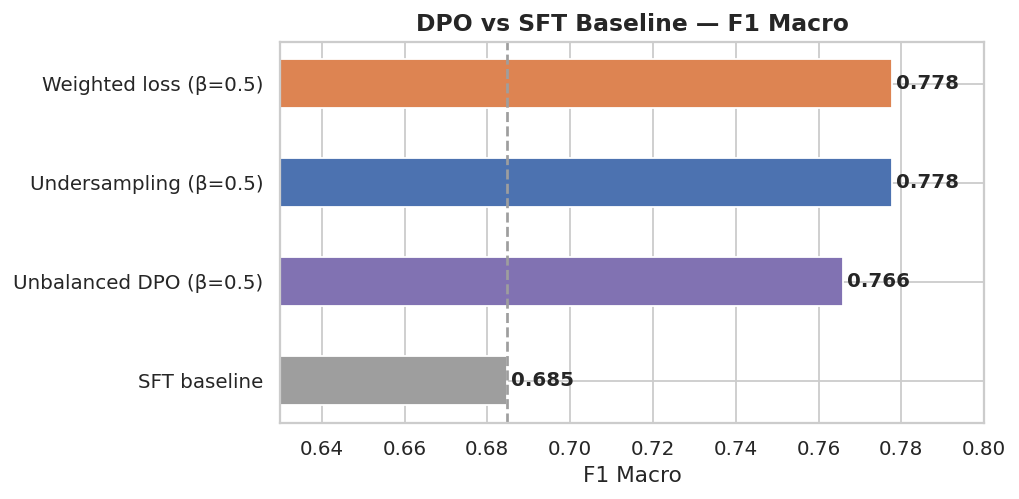

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

KEY_RUNS = [
    ("SFT baseline",           "data/predictions/sft_baseline/test_predictions.jsonl",         "#9e9e9e"),
    ("Unbalanced DPO (β=0.5)", "data/predictions/dpo_sweep/run_01/test_predictions.jsonl",     "#8172b2"),
    ("Undersampling (β=0.5)",  "data/predictions/dpo_sweep/run_02/test_predictions.jsonl",     "#4c72b0"),
    ("Weighted loss (β=0.5)",  "data/predictions/dpo_sweep/run_04/test_predictions.jsonl",     "#dd8452"),
]

rows = []
for label, relpath, col in KEY_RUNS:
    p, g, _ = load_predictions(ROOT / relpath)
    m = compute_metrics(p, g)
    rows.append({"label": label, "f1_macro": m["f1_macro"],
                 "f1_binary": m["f1_binary"], "color": col})

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, metric, title, paper_val in [
    (axes[0], "f1_macro",  "F1 Macro\n(internal DPO comparison)", None),
    (axes[1], "f1_binary", "F1 Binary — harmful class\n(comparable to paper Table 1)", 0.697),
]:
    vals = [r[metric] for r in rows]
    bars = ax.barh([r["label"] for r in rows], vals,
                   color=[r["color"] for r in rows], edgecolor="white", height=0.5)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", ha="left", fontsize=10, fontweight="bold")
    ax.axvline(rows[0][metric], color="#9e9e9e", linestyle="--", linewidth=1.5,
               label=f"SFT ({rows[0][metric]:.3f})")
    if paper_val:
        ax.axvline(paper_val, color="black", linestyle=":", linewidth=1.5,
                   label=f"Paper SFT ({paper_val:.3f})")
    ax.set_xlabel("Score"); ax.set_xlim(0.63, 0.82)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("DPO vs SFT — Macro F1 and Binary F1 (harmful)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Conclusion

### Best configuration
**β = 0.5, undersampling (balanced pairs), 1 epoch, no label smoothing**  
(runs 02 and 11 both reach F1-macro = 0.778)

### Key findings

| Finding | Detail |
|---------|--------|
| Imbalance causes safe bias | Unbalanced training → model predicts more safe → lower harmful recall |
| Balancing fixes it | Undersampling 510→364 safe pairs restores 50/50 balance |
| Both balancing methods work equally | Undersampling ≈ weighted loss (both 0.778) |
| β sweet spot: 0.4–0.5 | β < 0.2 produces malformed outputs; β > 0.6 slightly degrades |
| 1 epoch is optimal | 2 epochs: −0.026 F1, 3 epochs: −0.065 F1 |
| Label smoothing hurts | ls=0.05 consistently degrades both methods |
| SFT → best DPO | **+0.093 F1-macro** (+13.6%), safe F1: 0.644 → 0.776 |

The gain is primarily in **safe F1** — DPO corrects the SFT model's tendency  
to over-predict harmful, without significantly sacrificing harmful recall.